# 타이타닉호 생존 데이터 분석

웹에서 타이타닉호 승객 데이터를 불러와 성별에 따른 생존율을 비교합니다.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# seaborn 공개 데이터 저장소에서 타이타닉 데이터셋을 불러옵니다.
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(url)

pd.set_option("display.max_columns", None)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 데이터 기본 정보 확인

In [2]:
print(f"데이터 행 수: {titanic.shape[0]:,}")
print(f"데이터 열 수: {titanic.shape[1]:,}")
print("\n결측치 개수:")
display(titanic.isnull().sum())
print("\n성별별 승객 수:")
display(titanic["sex"].value_counts())

데이터 행 수: 891
데이터 열 수: 15

결측치 개수:


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


성별별 승객 수:


sex
male      577
female    314
Name: count, dtype: int64

## 성별 생존율 계산

`survived` 열의 평균은 생존 여부(생존=1, 사망=0)의 평균이므로 성별별 생존율이 됩니다.

In [3]:
gender_summary = (
    titanic.groupby("sex")
    .agg(
        승객수=("survived", "size"),
        생존자수=("survived", "sum"),
        생존율=("survived", "mean"),
    )
    .reindex(["male", "female"])
)
gender_summary["생존율(%)"] = gender_summary["생존율"] * 100
display(gender_summary.round({"생존율": 3, "생존율(%)": 1}))

,승객수,생존자수,생존율,생존율(%)
sex,,,,
male,577,109,0.189,18.9
female,314,233,0.742,74.2


## 남성과 여성의 생존비율 바차트

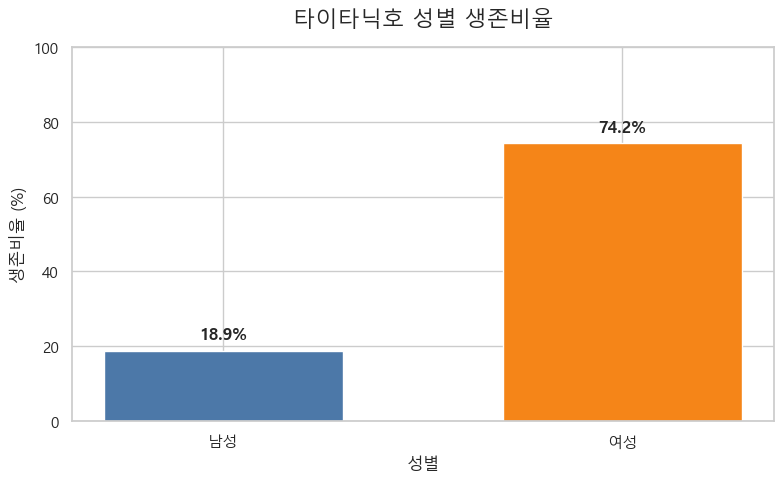

In [7]:
sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False

# 실행 환경에 설치된 한글 폰트를 자동으로 선택합니다.
korean_fonts = ["Malgun Gothic", "NanumGothic", "Noto Sans KR"]
available_fonts = {font.name for font in fm.fontManager.ttflist}
selected_font = next(
    (font for font in korean_fonts if font in available_fonts),
    "DejaVu Sans",
)
plt.rcParams["font.family"] = selected_font

labels = ["남성", "여성"]
survival_rates = gender_summary.loc[["male", "female"], "생존율(%)"].values
colors = ["#4C78A8", "#F58518"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, survival_rates, color=colors, width=0.6)
ax.set_title("타이타닉호 성별 생존비율", fontsize=16, pad=15)
ax.set_xlabel("성별")
ax.set_ylabel("생존비율 (%)")
ax.set_ylim(0, 100)

for bar, rate in zip(bars, survival_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 2,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 분석 결과

위 바차트에서 확인할 수 있듯이 이 데이터셋에서는 여성의 생존율이 남성보다 높습니다. 정확한 수치는 위의 요약표와 차트의 막대 위 레이블에서 확인할 수 있습니다.